# Preprocessing — Pourquoi et Comment

Ce notebook explique **chaque etape de nettoyage** avec la justification de son utilite,  
et montre les donnees **avant** et **apres** chaque transformation.

---

| Etape | Transformation | Pourquoi |
|---|---|---|
| 1 | Suppression `patient_id` | Identifiant sans valeur predictive |
| 2 | Decomposition `blood_pressure` | String inutilisable -> 2 features numeriques |
| 3 | Encodage binaire Yes/No -> 0/1 | Les ML travaillent avec des nombres |
| 4 | One-hot `gender` et `discharge_destination` | Variables nominales sans ordre |
| 5 | Split train/test stratifie 80/20 | Evaluer sur la distribution reelle |
| 6 | StandardScaler sur variables continues | Mettre toutes les echelles sur un pied d'egalite |
| 7 | SMOTE sur train uniquement | Corriger le desequilibre 12%/88% |

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 100

DATA_PATH = '../data/hospital_readmissions_30k.csv'
TARGET    = 'readmitted_30_days'

def banner(title):
    """Affiche un separateur visuel."""
    print('\n' + '='*60)
    print(f'  {title}')
    print('='*60)

---
## Donnees brutes

In [2]:
df_raw = pd.read_csv(DATA_PATH, sep=';')

print(f'Shape brut : {df_raw.shape}')
print(f'Colonnes   : {df_raw.columns.tolist()}')
display(df_raw.head(5))

Shape brut : (30000, 12)
Colonnes   : ['patient_id', 'age', 'gender', 'blood_pressure', 'cholesterol', 'bmi', 'diabetes', 'hypertension', 'medication_count', 'length_of_stay', 'discharge_destination', 'readmitted_30_days']


,patient_id,age,gender,blood_pressure,cholesterol,bmi,diabetes,hypertension,medication_count,length_of_stay,discharge_destination,readmitted_30_days
0,1,74,Other,130/72,240,31.5,Yes,No,5,1,Nursing_Facility,Yes
1,2,46,Female,120/92,292,36.3,No,No,4,3,Nursing_Facility,No
2,3,89,Other,135/78,153,30.3,No,Yes,1,1,Home,No
3,4,84,Female,123/80,153,31.5,No,Yes,3,10,Home,No
4,5,32,Other,135/84,205,18.4,No,Yes,6,4,Nursing_Facility,No


---
## Etape 1 — Suppression de `patient_id`

### Pourquoi ?

`patient_id` est un **identifiant technique** attribue arbitrairement a chaque patient.  
Il ne contient **aucune information medicale** : deux patients avec des IDs consecutifs  
n'ont pas plus de points communs que deux patients quelconques.

**Consequences si on le garde :**
- Certains modeles (arbres de decision, XGBoost) pourraient utiliser l'ID comme feature,  
  ce qui introduirait du **bruit** et du **surapprentissage**.
- L'ID n'est pas disponible pour de nouveaux patients en production.

**Regle generale :** supprimer toutes les colonnes identifiants (id, nom, numero de secu, etc.).

In [3]:
banner('AVANT — avec patient_id')
print(f'Colonnes ({df_raw.shape[1]}) : {df_raw.columns.tolist()}')
print(f'Exemple  : patient_id = {df_raw["patient_id"].iloc[:5].tolist()}')
print(f'Unique   : {df_raw["patient_id"].nunique()} valeurs distinctes')

df = df_raw.drop(columns=['patient_id'])

banner('APRES — sans patient_id')
print(f'Colonnes ({df.shape[1]}) : {df.columns.tolist()}')


  AVANT — avec patient_id
Colonnes (12) : ['patient_id', 'age', 'gender', 'blood_pressure', 'cholesterol', 'bmi', 'diabetes', 'hypertension', 'medication_count', 'length_of_stay', 'discharge_destination', 'readmitted_30_days']
Exemple  : patient_id = [1, 2, 3, 4, 5]
Unique   : 30000 valeurs distinctes

  APRES — sans patient_id
Colonnes (11) : ['age', 'gender', 'blood_pressure', 'cholesterol', 'bmi', 'diabetes', 'hypertension', 'medication_count', 'length_of_stay', 'discharge_destination', 'readmitted_30_days']


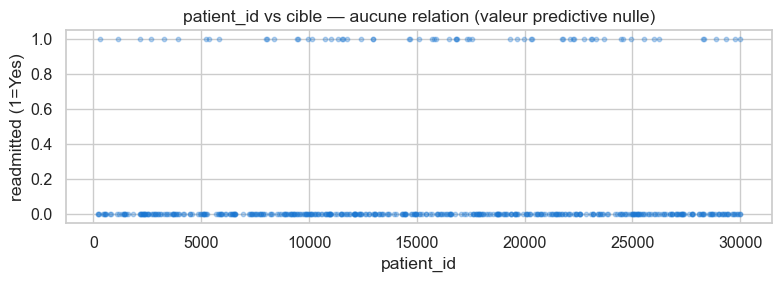

In [4]:
# Visualisation : l'ID n'est pas corre avec la cible
fig, ax = plt.subplots(figsize=(8, 3))
ax.scatter(
    df_raw.sample(500, random_state=42)['patient_id'],
    (df_raw.sample(500, random_state=42)[TARGET] == 'Yes').astype(int),
    alpha=0.3, s=10, color='#1976d2'
)
ax.set_xlabel('patient_id')
ax.set_ylabel('readmitted (1=Yes)')
ax.set_title('patient_id vs cible — aucune relation (valeur predictive nulle)')
plt.tight_layout()
plt.show()

---
## Etape 2 — Decomposition de `blood_pressure`

### Pourquoi ?

`blood_pressure` est stocke comme la chaine `'130/72'` — un **format texte** que les  
algorithmes ML ne peuvent pas traiter directement.

Cette valeur encode en realite **deux mesures medicales distinctes** :
- **Systolique** (`bp_sys`) : pression quand le coeur se contracte — indicateur de risque cardiovasculaire
- **Diastolique** (`bp_dia`) : pression entre deux battements — indicateur de rigidite arterielle

En gardant la chaine brute, on perdrait ces deux signaux.  
En decomposant, on cree **2 features numeriques** utilisables et interpretables.

In [5]:
banner('AVANT — blood_pressure comme string')
print(f'Type    : {df["blood_pressure"].dtype}')
print(f'Exemple : {df["blood_pressure"].head(6).tolist()}')
print(f'Unique  : {df["blood_pressure"].nunique()} valeurs distinctes')
display(df[['blood_pressure', TARGET]].head(5))

# Decomposition
bp = df['blood_pressure'].str.split('/', expand=True).astype(float)
df.insert(df.columns.get_loc('blood_pressure'),     'bp_sys', bp[0])
df.insert(df.columns.get_loc('blood_pressure') + 1, 'bp_dia', bp[1])
df = df.drop(columns=['blood_pressure'])

banner('APRES — bp_sys et bp_dia (numeriques)')
print(f'Type bp_sys : {df["bp_sys"].dtype}  |  Type bp_dia : {df["bp_dia"].dtype}')
print(f'bp_sys : min={df["bp_sys"].min():.0f}  max={df["bp_sys"].max():.0f}  moy={df["bp_sys"].mean():.1f}')
print(f'bp_dia : min={df["bp_dia"].min():.0f}  max={df["bp_dia"].max():.0f}  moy={df["bp_dia"].mean():.1f}')
display(df[['bp_sys', 'bp_dia', TARGET]].head(5))


  AVANT — blood_pressure comme string
Type    : object
Exemple : ['130/72', '120/92', '135/78', '123/80', '135/84', '139/100']
Unique  : 1581 valeurs distinctes


,blood_pressure,readmitted_30_days
0,130/72,Yes
1,120/92,No
2,135/78,No
3,123/80,No
4,135/84,No



  APRES — bp_sys et bp_dia (numeriques)
Type bp_sys : float64  |  Type bp_dia : float64
bp_sys : min=110  max=160  moy=135.0
bp_dia : min=70  max=100  moy=85.0


,bp_sys,bp_dia,readmitted_30_days
0,130.0,72.0,Yes
1,120.0,92.0,No
2,135.0,78.0,No
3,123.0,80.0,No
4,135.0,84.0,No


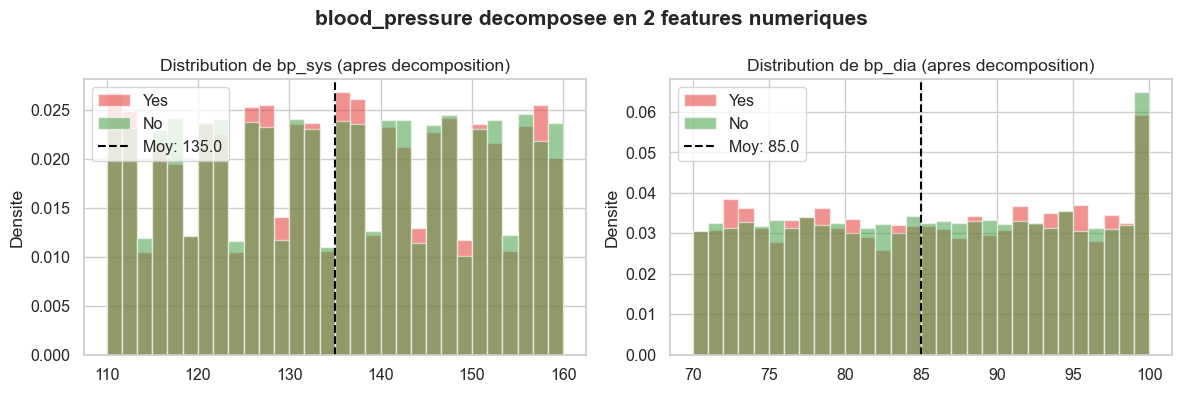

In [6]:
# Distribution des 2 nouvelles features
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

PALETTE = {'Yes': '#e53935', 'No': '#43a047'}

for ax, col in zip(axes, ['bp_sys', 'bp_dia']):
    for label, color in PALETTE.items():
        df[df[TARGET]==label][col].hist(
            bins=30, ax=ax, alpha=0.55, color=color,
            density=True, label=label
        )
    ax.axvline(df[col].mean(), color='black', linestyle='--',
               linewidth=1.5, label=f'Moy: {df[col].mean():.1f}')
    ax.set_title(f'Distribution de {col} (apres decomposition)')
    ax.set_ylabel('Densite')
    ax.legend()

plt.suptitle('blood_pressure decomposee en 2 features numeriques', fontweight='bold')
plt.tight_layout()
plt.show()

---
## Etape 3 — Encodage binaire Yes/No -> 0/1

### Pourquoi ?

Les colonnes `diabetes`, `hypertension` et `readmitted_30_days` sont des variables **oui/non**.  
Les algorithmes ML (regression logistique, XGBoost, etc.) **ne peuvent pas traiter du texte** —  
ils ont besoin de nombres.

**Pourquoi 0/1 et pas LabelEncoder ?**  
LabelEncoder assigne les codes alphabetiquement (No=0, Yes=1), ce qui donne le meme resultat  
ici. Mais le mapping explicite `Yes->1 / No->0` est plus lisible et reproductible.  
Pour des variables **nominales sans ordre** (comme gender), on utilisera plutot le one-hot  
encoding (etape 4).

In [7]:
binary_cols = ['diabetes', 'hypertension']

banner('AVANT — valeurs texte Yes/No')
display(df[binary_cols + [TARGET]].head(8))
print('Types :', df[binary_cols].dtypes.to_dict())

# Encodage
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})
df[TARGET] = df[TARGET].map({'Yes': 1, 'No': 0})

banner('APRES — valeurs 0/1')
display(df[binary_cols + [TARGET]].head(8))
print('Types :', df[binary_cols].dtypes.to_dict())
print(f'\nDistribution cible apres encodage :')
print(df[TARGET].value_counts().to_dict())


  AVANT — valeurs texte Yes/No


,diabetes,hypertension,readmitted_30_days
0,Yes,No,Yes
1,No,No,No
2,No,Yes,No
3,No,Yes,No
4,No,Yes,No
5,No,Yes,No
6,No,Yes,No
7,No,No,No


Types : {'diabetes': dtype('O'), 'hypertension': dtype('O')}

  APRES — valeurs 0/1


,diabetes,hypertension,readmitted_30_days
0,1,0,1
1,0,0,0
2,0,1,0
3,0,1,0
4,0,1,0
5,0,1,0
6,0,1,0
7,0,0,0


Types : {'diabetes': dtype('int64'), 'hypertension': dtype('int64')}

Distribution cible apres encodage :
{0: 26326, 1: 3674}


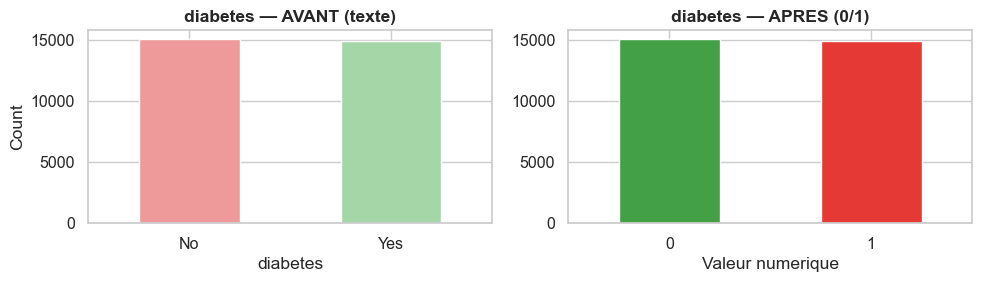

In [8]:
# Visualisation avant / apres (sur diabetes)
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

# Avant (depuis df_raw)
df_raw['diabetes'].value_counts().plot(kind='bar', ax=axes[0],
    color=['#ef9a9a', '#a5d6a7'], edgecolor='white', rot=0)
axes[0].set_title('diabetes — AVANT (texte)', fontweight='bold')
axes[0].set_ylabel('Count')

# Apres
df['diabetes'].value_counts().sort_index().plot(kind='bar', ax=axes[1],
    color=['#43a047', '#e53935'], edgecolor='white', rot=0)
axes[1].set_title('diabetes — APRES (0/1)', fontweight='bold')
axes[1].set_xlabel('Valeur numerique')

plt.tight_layout()
plt.show()

---
## Etape 4 — One-Hot Encoding de `gender` et `discharge_destination`

### Pourquoi One-Hot et pas Label Encoding ?

**Label Encoding** attribue un entier (0, 1, 2...) a chaque modalite.  
Cela introduce un **ordre artificiel** : 0 < 1 < 2 laisse entendre que la modalite 2  
est "plus grande" que la modalite 1, ce qui n'a aucun sens pour `gender` ou `discharge_destination`.

**One-Hot Encoding** cree une **colonne binaire par modalite** — il n'y a aucun ordre implicite.

| Variable | Modalites | Colonnes creees |
|---|---|---|
| `gender` | Female, Male, Other | `gender_Female`, `gender_Male`, `gender_Other` |
| `discharge_destination` | Home, Nursing_Facility, Rehab | `dest_Home`, `dest_Nursing_Facility`, `dest_Rehab` |

In [9]:
banner('AVANT — colonnes texte')
print('gender unique         :', df['gender'].unique().tolist())
print('discharge unique      :', df['discharge_destination'].unique().tolist())
print(f'Nombre de colonnes   : {df.shape[1]}')
display(df[['gender', 'discharge_destination']].head(5))

# One-hot encoding
df = pd.get_dummies(df, columns=['gender'],
                    prefix='gender', drop_first=False, dtype=int)
df = pd.get_dummies(df, columns=['discharge_destination'],
                    prefix='dest',   drop_first=False, dtype=int)

banner('APRES — colonnes one-hot')
ohe_cols = [c for c in df.columns if c.startswith('gender_') or c.startswith('dest_')]
print('Nouvelles colonnes :', ohe_cols)
print(f'Nombre de colonnes : {df.shape[1]}')
display(df[ohe_cols].head(5))


  AVANT — colonnes texte
gender unique         : ['Other', 'Female', 'Male']
discharge unique      : ['Nursing_Facility', 'Home', 'Rehab']
Nombre de colonnes   : 12


,gender,discharge_destination
0,Other,Nursing_Facility
1,Female,Nursing_Facility
2,Other,Home
3,Female,Home
4,Other,Nursing_Facility



  APRES — colonnes one-hot
Nouvelles colonnes : ['gender_Female', 'gender_Male', 'gender_Other', 'dest_Home', 'dest_Nursing_Facility', 'dest_Rehab']
Nombre de colonnes : 16


,gender_Female,gender_Male,gender_Other,dest_Home,dest_Nursing_Facility,dest_Rehab
0,0,0,1,0,1,0
1,1,0,0,0,1,0
2,0,0,1,1,0,0
3,1,0,0,1,0,0
4,0,0,1,0,1,0


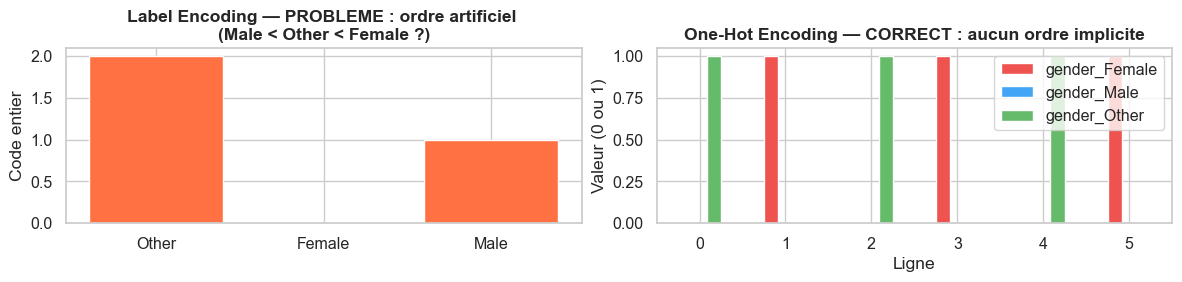


Etat du DataFrame apres etapes 1-4 :
Shape : (30000, 16)
Colonnes : ['age', 'bp_sys', 'bp_dia', 'cholesterol', 'bmi', 'diabetes', 'hypertension', 'medication_count', 'length_of_stay', 'readmitted_30_days', 'gender_Female', 'gender_Male', 'gender_Other', 'dest_Home', 'dest_Nursing_Facility', 'dest_Rehab']


In [10]:
# Comparaison Label Encoding vs One-Hot Encoding sur gender
fig, axes = plt.subplots(1, 2, figsize=(12, 3))

# Label encoding (simule)
le_demo = df_raw['gender'].astype('category').cat.codes
axes[0].bar(df_raw['gender'].unique(),
            [le_demo[df_raw['gender']==g].iloc[0] for g in df_raw['gender'].unique()],
            color='#ff7043', edgecolor='white')
axes[0].set_title('Label Encoding — PROBLEME : ordre artificiel \n(Male < Other < Female ?)', fontweight='bold')
axes[0].set_ylabel('Code entier')

# One-hot
ohe_preview = df[['gender_Female','gender_Male','gender_Other']].head(6)
ohe_preview.plot(kind='bar', ax=axes[1], color=['#ef5350','#42a5f5','#66bb6a'],
                 edgecolor='white', rot=0)
axes[1].set_title('One-Hot Encoding — CORRECT : aucun ordre implicite', fontweight='bold')
axes[1].set_ylabel('Valeur (0 ou 1)')
axes[1].set_xlabel('Ligne')

plt.tight_layout()
plt.show()

print('\nEtat du DataFrame apres etapes 1-4 :')
print(f'Shape : {df.shape}')
print(f'Colonnes : {df.columns.tolist()}')

---
## Etape 5 — Split Train / Test stratifie (80/20)

### Pourquoi stratifier ?

Avec **12.2% de positifs**, un split aleatoire simple pourrait produire des partitions  
avec des proportions tres differentes de la cible — par hasard, le test pourrait avoir  
20% de positifs ou seulement 5%.

**`stratify=y`** garantit que **chaque ensemble respecte la meme proportion** que l'original.

### Pourquoi le test set reste intact (sans SMOTE) ?

Le test set **simule la realite** : en production, on verra ~12% de readmissions.  
Modifier le test set biaiserait l'evaluation — les metriques ne refleteraient plus  
les vraies performances du modele en conditions reelles.

In [11]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'X_train : {X_train.shape}  |  y_train : {y_train.shape}')
print(f'X_test  : {X_test.shape}   |  y_test  : {y_test.shape}')

train_pos = y_train.mean() * 100
test_pos  = y_test.mean()  * 100
all_pos   = y.mean()       * 100

print(f'\nTaux de positifs :')
print(f'  Dataset complet : {all_pos:.2f}%')
print(f'  Train           : {train_pos:.2f}%  <- stratifie')
print(f'  Test            : {test_pos:.2f}%   <- stratifie')

X_train : (24000, 15)  |  y_train : (24000,)
X_test  : (6000, 15)   |  y_test  : (6000,)

Taux de positifs :
  Dataset complet : 12.25%
  Train           : 12.25%  <- stratifie
  Test            : 12.25%   <- stratifie


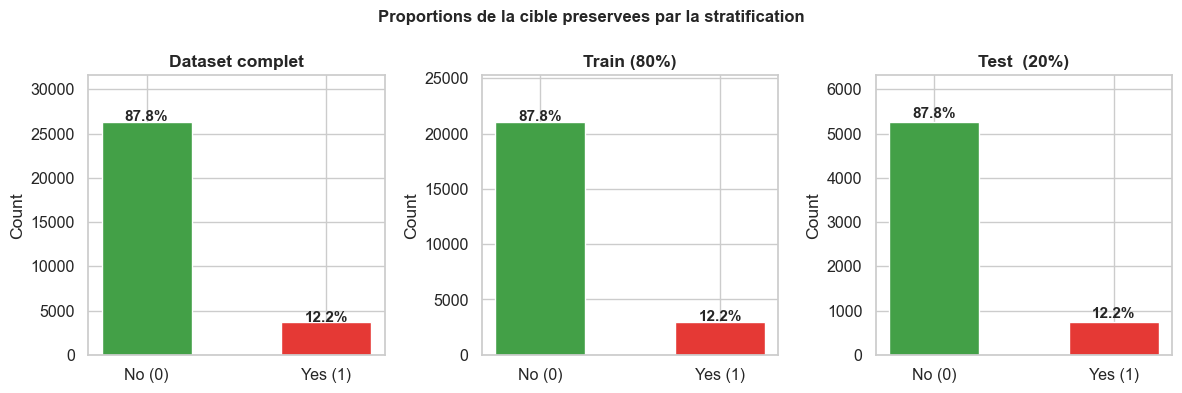

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

datasets = [
    ('Dataset complet', y),
    ('Train (80%)',     y_train),
    ('Test  (20%)',     y_test),
]
colors = [['#43a047','#e53935']] * 3

for ax, (title, series), clr in zip(axes, datasets, colors):
    counts = series.value_counts().sort_index()
    pcts   = series.value_counts(normalize=True).sort_index() * 100
    bars = ax.bar(['No (0)', 'Yes (1)'], counts.values, color=clr, edgecolor='white', width=0.5)
    for bar, p in zip(bars, pcts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                f'{p:.1f}%', ha='center', fontsize=11, fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Count')
    ax.set_ylim(0, counts.max() * 1.2)

plt.suptitle('Proportions de la cible preservees par la stratification',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Etape 6 — StandardScaler sur variables continues

### Pourquoi scaler ?

Les variables continues ont des **echelles tres differentes** :
- `cholesterol` varie entre 150 et 300
- `bmi` varie entre 18 et 40  
- `age` varie entre 18 et 90

Les algorithmes bases sur des **distances** (regression logistique) ou des **gradients**  
sont sensibles a ces ecarts : une variable a grande echelle domine les autres.

**StandardScaler** centre (soustrait la moyenne) et reduit (divise par l'ecart-type) :  
chaque variable a ensuite **moyenne = 0** et **ecart-type = 1**.

### Regle critique : fitter sur train, transformer train ET test

Si on fittait le scaler sur l'ensemble complet, les statistiques du test set  
**contamineraient** le scaler — le modele aurait vu des informations du futur (**data leakage**).

In [13]:
NUMERICAL_COLS = ['age', 'cholesterol', 'bmi', 'medication_count', 'length_of_stay',
                  'bp_sys', 'bp_dia']

banner('AVANT scaling — statistiques des variables continues (train)')
display(X_train[NUMERICAL_COLS].describe().round(2))

# Fit sur train uniquement
scaler = StandardScaler()
X_train_s = X_train.copy()
X_test_s  = X_test.copy()
X_train_s[NUMERICAL_COLS] = scaler.fit_transform(X_train[NUMERICAL_COLS])
X_test_s[NUMERICAL_COLS]  = scaler.transform(X_test[NUMERICAL_COLS])

banner('APRES scaling — statistiques (train)')
display(X_train_s[NUMERICAL_COLS].describe().round(4))
print('=> Chaque colonne : moyenne ~= 0, ecart-type ~= 1')


  AVANT scaling — statistiques des variables continues (train)


,age,cholesterol,bmi,medication_count,length_of_stay,bp_sys,bp_dia
count,24000.00,24000.00,24000.00,24000.00,24000.00,24000.00,24000.00
mean,53.84,225.22,28.98,5.03,5.51,135.01,85.02
std,21.07,43.68,6.35,3.17,2.87,14.67,8.93
min,18.00,150.00,18.00,0.00,1.00,110.00,70.00
25%,36.00,188.00,23.50,2.00,3.00,122.00,77.00
50%,54.00,225.00,28.90,5.00,6.00,135.00,85.00
75%,72.00,263.00,34.60,8.00,8.00,148.00,93.00
max,90.00,300.00,40.00,10.00,10.00,160.00,100.00



  APRES scaling — statistiques (train)


,age,cholesterol,bmi,medication_count,length_of_stay,bp_sys,bp_dia
count,24000.0000,24000.000,24000.0000,24000.0000,24000.0000,24000.0000,24000.0000
mean,0.0000,-0.000,0.0000,-0.0000,-0.0000,0.0000,-0.0000
std,1.0000,1.000,1.0000,1.0000,1.0000,1.0000,1.0000
min,-1.7013,-1.722,-1.7281,-1.5875,-1.5698,-1.7055,-1.6826
25%,-0.8469,-0.852,-0.8621,-0.9560,-0.8734,-0.8873,-0.8986
50%,0.0074,-0.005,-0.0118,-0.0089,0.1711,-0.0010,-0.0026
75%,0.8617,0.865,0.8857,0.9383,0.8674,0.8854,0.8935
max,1.7160,1.712,1.7359,1.5698,1.5638,1.7036,1.6775


=> Chaque colonne : moyenne ~= 0, ecart-type ~= 1


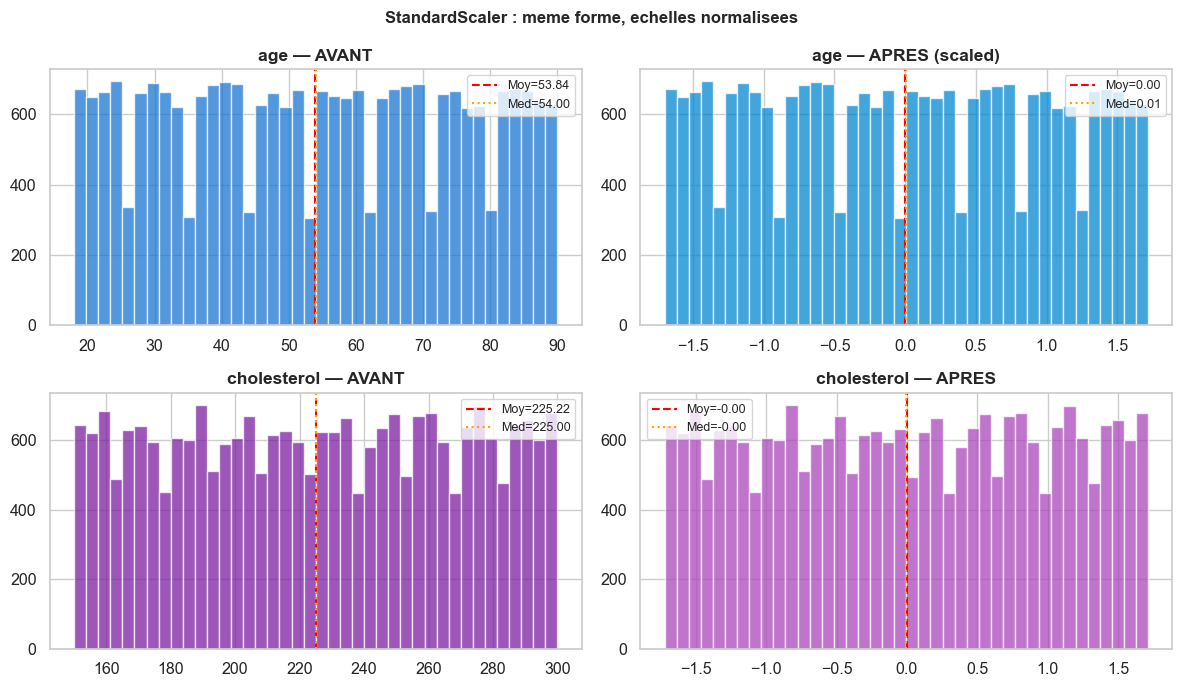

In [14]:
# Comparaison visuelle avant/apres sur age et cholesterol
fig, axes = plt.subplots(2, 2, figsize=(12, 7))

pairs = [
    (axes[0,0], X_train['age'],          'age — AVANT',          '#1976d2'),
    (axes[0,1], X_train_s['age'],        'age — APRES (scaled)', '#0288d1'),
    (axes[1,0], X_train['cholesterol'],  'cholesterol — AVANT',  '#7b1fa2'),
    (axes[1,1], X_train_s['cholesterol'],'cholesterol — APRES',  '#ab47bc'),
]

for ax, data, title, color in pairs:
    ax.hist(data, bins=40, color=color, alpha=0.75, edgecolor='white')
    ax.axvline(data.mean(), color='red', linestyle='--', linewidth=1.5,
               label=f'Moy={data.mean():.2f}')
    ax.axvline(data.median(), color='orange', linestyle=':', linewidth=1.5,
               label=f'Med={data.median():.2f}')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('StandardScaler : meme forme, echelles normalisees', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
# Demonstration du data leakage
print('=== Demonstration du data leakage ===')
print()
print('CORRECT   : scaler.fit(X_train) puis scaler.transform(X_test)')
print('           => le scaler ignore les statistiques du test set')
print()
print('INCORRECT : scaler.fit(X_train + X_test) puis transform')
print('           => la moyenne/std du test contamine le scaler')
print('           => le modele a vu des infos futures = evaluation biaisee')
print()
mean_train = X_train['age'].mean()
mean_all   = X['age'].mean()
print(f'Moyenne age (train seul) : {mean_train:.3f}')
print(f'Moyenne age (complet)    : {mean_all:.3f}')
print(f'Difference               : {abs(mean_train - mean_all):.3f} — si dataset grand, faible,')
print(f'mais la REGLE reste essentielle en pratique professionnelle.')

=== Demonstration du data leakage ===

CORRECT   : scaler.fit(X_train) puis scaler.transform(X_test)
           => le scaler ignore les statistiques du test set

INCORRECT : scaler.fit(X_train + X_test) puis transform
           => la moyenne/std du test contamine le scaler
           => le modele a vu des infos futures = evaluation biaisee

Moyenne age (train seul) : 53.844
Moyenne age (complet)    : 53.884
Difference               : 0.040 — si dataset grand, faible,
mais la REGLE reste essentielle en pratique professionnelle.


---
## Etape 7 — SMOTE : corriger le desequilibre

### Pourquoi le desequilibre est un probleme ?

Avec **12.2% de positifs** (readmis) et **87.8% de negatifs** :  
- Un modele stupide qui predit **toujours "Non"** obtient **87.8% d'accuracy** sans rien apprendre.
- Le modele est "recompense" pour ignorer la classe minoritaire.
- **Recall** sur la classe positive sera proche de **0%**.

Or dans le contexte medical, **manquer un patient qui sera readmis est couteux** —  
le recall sur la classe positive est la metrique la plus importante.

### Pourquoi SMOTE plutot que simple sur-echantillonnage ?

| Methode | Principe | Probleme |
|---|---|---|
| Sur-echantillonnage naif | Copier des exemples existants | Surapprentissage sur les copies |
| Sous-echantillonnage | Supprimer des exemples majoritaires | Perte d'information |
| **SMOTE** | **Generer des exemples synthetiques** par interpolation | Meilleure generalisation |

SMOTE (**S**ynthetic **M**inority **O**ver-sampling **TE**chnique) cree de nouveaux  
exemples minoritaires en interpolant entre des voisins proches existants.

### Regle : SMOTE sur train uniquement

Le test set doit rester intact (distribution reelle) pour evaluer les vraies performances.

In [16]:
banner('AVANT SMOTE — desequilibre sur train')
before = y_train.value_counts().sort_index()
print(f'Classe 0 (Non-readmis) : {before[0]:,}  ({before[0]/len(y_train)*100:.1f}%)')
print(f'Classe 1 (Readmis)     : {before[1]:,}  ({before[1]/len(y_train)*100:.1f}%)')
print(f'Ratio de desequilibre  : 1:{before[0]//before[1]}')


  AVANT SMOTE — desequilibre sur train
Classe 0 (Non-readmis) : 21,061  (87.8%)
Classe 1 (Readmis)     : 2,939  (12.2%)
Ratio de desequilibre  : 1:7


In [17]:
# Application SMOTE
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_s, y_train)

banner('APRES SMOTE — train reequilibre')
after = pd.Series(y_train_sm).value_counts().sort_index()
print(f'Classe 0 (Non-readmis) : {after[0]:,}  ({after[0]/len(y_train_sm)*100:.1f}%)')
print(f'Classe 1 (Readmis)     : {after[1]:,}  ({after[1]/len(y_train_sm)*100:.1f}%)')
print(f'Nouvelles lignes generees : {after[1] - before[1]:,}')
print(f'\nX_train avant : {X_train_s.shape}')
print(f'X_train apres : {X_train_sm.shape}')
print(f'\nTest set inchange  : {X_test_s.shape}  (distribution reelle preservee)')


  APRES SMOTE — train reequilibre
Classe 0 (Non-readmis) : 21,061  (50.0%)
Classe 1 (Readmis)     : 21,061  (50.0%)
Nouvelles lignes generees : 18,122

X_train avant : (24000, 15)
X_train apres : (42122, 15)

Test set inchange  : (6000, 15)  (distribution reelle preservee)


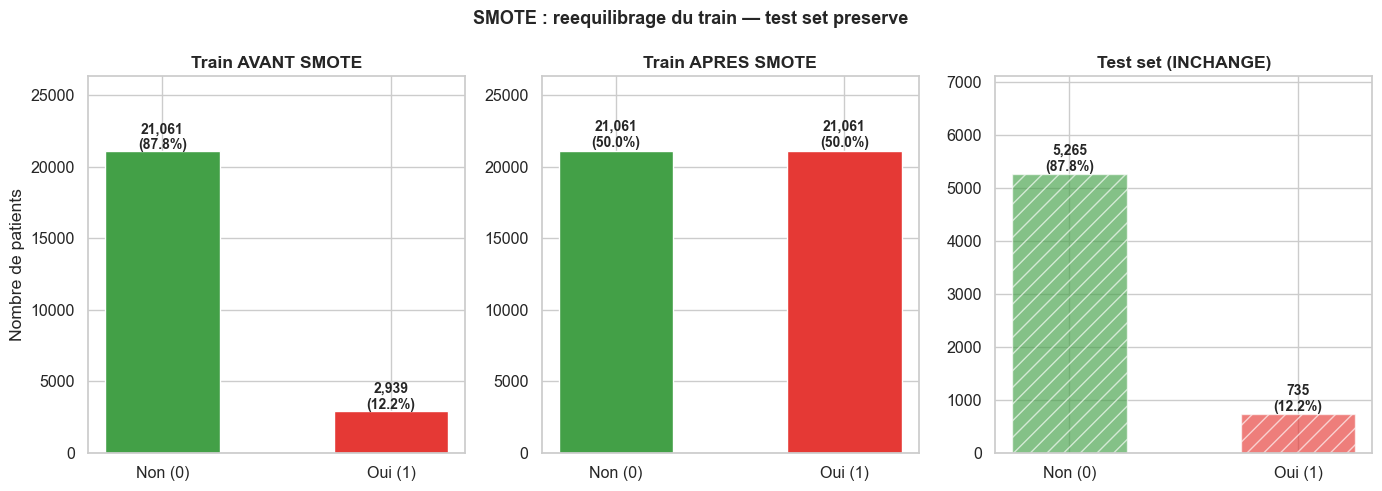

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

cls_colors = ['#43a047', '#e53935']

# Avant SMOTE
ax = axes[0]
b = before.values
bars = ax.bar(['Non (0)', 'Oui (1)'], b, color=cls_colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, b):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+150,
            f'{val:,}\n({val/b.sum()*100:.1f}%)', ha='center', fontsize=10, fontweight='bold')
ax.set_title('Train AVANT SMOTE', fontweight='bold')
ax.set_ylabel('Nombre de patients')
ax.set_ylim(0, max(b)*1.25)

# Apres SMOTE
ax = axes[1]
a = after.values
bars = ax.bar(['Non (0)', 'Oui (1)'], a, color=cls_colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, a):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+300,
            f'{val:,}\n({val/a.sum()*100:.1f}%)', ha='center', fontsize=10, fontweight='bold')
ax.set_title('Train APRES SMOTE', fontweight='bold')
ax.set_ylim(0, max(a)*1.25)

# Test set (inchange)
ax = axes[2]
t = y_test.value_counts().sort_index().values
bars = ax.bar(['Non (0)', 'Oui (1)'], t, color=cls_colors, edgecolor='white',
              width=0.5, alpha=0.65, hatch='//')
for bar, val in zip(bars, t):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
            f'{val:,}\n({val/t.sum()*100:.1f}%)', ha='center', fontsize=10, fontweight='bold')
ax.set_title('Test set (INCHANGE)', fontweight='bold')
ax.set_ylim(0, max(t)*1.35)

plt.suptitle('SMOTE : reequilibrage du train — test set preserve',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

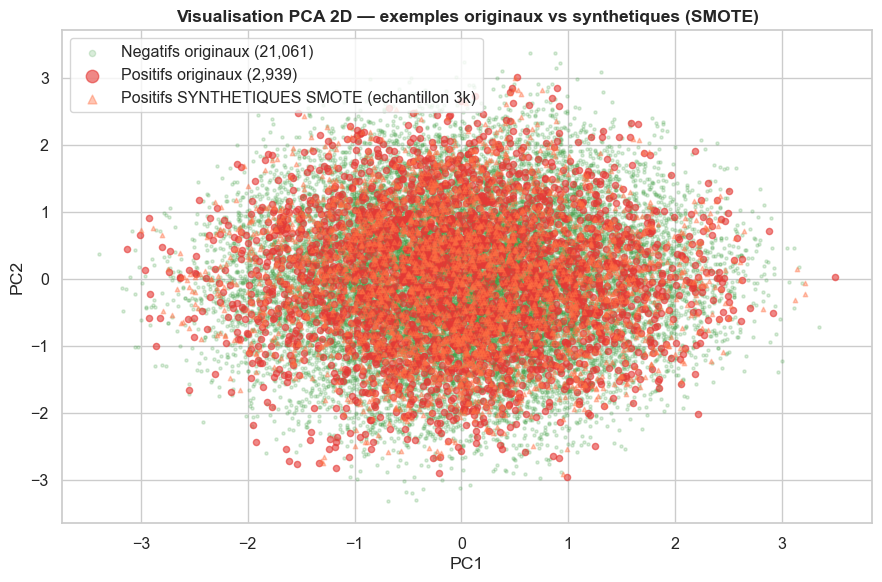

In [19]:
# Illustration du principe SMOTE : les points synthetiques sont generes PAR INTERPOLATION
# Visualisation sur 2 features (age et bmi) apres PCA en 2D
from sklearn.decomposition import PCA

# Comparaison des vrais positifs vs synthetiques sur les indices
n_original_pos = before[1]  # positifs avant SMOTE

# Reduire a 2D pour visualisation
pca = PCA(n_components=2, random_state=42)
X_2d_all = pca.fit_transform(X_train_sm)
n_orig_total = len(X_train_s)

fig, ax = plt.subplots(figsize=(9, 6))

# Negatifs originaux
neg_idx = np.where(y_train_sm[:n_orig_total] == 0)[0]
ax.scatter(X_2d_all[neg_idx, 0], X_2d_all[neg_idx, 1],
           s=5, alpha=0.2, color='#43a047', label=f'Negatifs originaux ({len(neg_idx):,})')

# Positifs originaux (dans le train d'origine)
pos_orig_idx = np.where((np.arange(len(y_train_sm)) < n_orig_total) &
                        (y_train_sm == 1))[0]
ax.scatter(X_2d_all[pos_orig_idx, 0], X_2d_all[pos_orig_idx, 1],
           s=20, alpha=0.6, color='#e53935', label=f'Positifs originaux ({len(pos_orig_idx):,})')

# Positifs synthetiques (generes par SMOTE)
pos_synth_idx = np.where((np.arange(len(y_train_sm)) >= n_orig_total) &
                         (y_train_sm == 1))[0]
if len(pos_synth_idx) > 0:
    sample = np.random.choice(pos_synth_idx, min(3000, len(pos_synth_idx)), replace=False)
    ax.scatter(X_2d_all[sample, 0], X_2d_all[sample, 1],
               s=10, alpha=0.4, color='#ff7043', marker='^',
               label=f'Positifs SYNTHETIQUES SMOTE (echantillon 3k)')

ax.set_title('Visualisation PCA 2D — exemples originaux vs synthetiques (SMOTE)',
             fontweight='bold')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend(markerscale=2)
plt.tight_layout()
plt.show()

---
## Resume du pipeline complet

In [20]:
print('=' * 60)
print('RESUME COMPLET DU PIPELINE DE PREPROCESSING')
print('=' * 60)

steps = [
    ('Donnees brutes',               f'{df_raw.shape[0]:,} lignes x {df_raw.shape[1]} col',      'Avant tout'),
    ('1. Suppression patient_id',    f'{df_raw.shape[0]:,} lignes x {df_raw.shape[1]-1} col',    'Pas de signal predictif'),
    ('2. Decomposition blood_press', '... x memes lignes, +1 col (bp_sys, bp_dia)',               '2 features num au lieu de 1 str'),
    ('3. Encodage Yes/No -> 0/1',    'diabetes, hypertension, cible numeriques',                  'Algebre ML impossible sur str'),
    ('4. One-Hot gender + dest',     f'+{len(ohe_cols)} colonnes binaires',                       'Pas d ordre dans modalites'),
    ('5. Split 80/20 stratifie',     f'Train={X_train.shape[0]:,} | Test={X_test.shape[0]:,}',   '12.2% positifs dans chaque'),
    ('6. StandardScaler (train)',    'moy=0 std=1 sur 7 vars continues',                          'Egalite des echelles, anti-leakage'),
    ('7. SMOTE (train seul)',        f'Train: {X_train_sm.shape[0]:,} lignes (50/50)',            'Corriger 12%/88% desequilibre'),
]

for name, result, reason in steps:
    print(f'  {name:<32} -> {result:<40}  [{reason}]')

print('\n' + '=' * 60)
print('SORTIE FINALE')
print('=' * 60)
print(f'  X_train : {X_train_sm.shape}  (reequilibre par SMOTE)')
print(f'  X_test  : {X_test_s.shape}   (distribution reelle)')
print(f'  Features: {X_train.columns.tolist()}')
print('=' * 60)

RESUME COMPLET DU PIPELINE DE PREPROCESSING
  Donnees brutes                   -> 30,000 lignes x 12 col                    [Avant tout]
  1. Suppression patient_id        -> 30,000 lignes x 11 col                    [Pas de signal predictif]
  2. Decomposition blood_press     -> ... x memes lignes, +1 col (bp_sys, bp_dia)  [2 features num au lieu de 1 str]
  3. Encodage Yes/No -> 0/1        -> diabetes, hypertension, cible numeriques  [Algebre ML impossible sur str]
  4. One-Hot gender + dest         -> +6 colonnes binaires                      [Pas d ordre dans modalites]
  5. Split 80/20 stratifie         -> Train=24,000 | Test=6,000                 [12.2% positifs dans chaque]
  6. StandardScaler (train)        -> moy=0 std=1 sur 7 vars continues          [Egalite des echelles, anti-leakage]
  7. SMOTE (train seul)            -> Train: 42,122 lignes (50/50)              [Corriger 12%/88% desequilibre]

SORTIE FINALE
  X_train : (42122, 15)  (reequilibre par SMOTE)
  X_test  : (6000